# Exploratory Data Analysis (EDA)

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

# Configure visualization aesthetics
sns.set(style="whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6)})

# Suppress any warnings for a cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

#Load dataset
df = pd.read_excel("Data/data_cleaned.xlsx", header=0)

## A - Station and Mode Analysis
**Stations and Their Characteristics:**
- How many unique stations are present in the datat?
- Which stations report the highest volumes of entries and exits (both total and per y)?
- Is there a correlation between station coverage (as indicated by the `Coverage` column) and the volume of traffic?

**Transport Modes:**
- What are the different transport modes found in the dataset, and how do their usage patterns compare?
- Is one mode significantly busier than the others in terms of passenger traffic?

### 1. Unique Stations
Determine how many unique stations are present in the dataset.

In [2]:
unique_stations = df['Station'].nunique()
print(f"There are {unique_stations} unique stations in the dataset.")

There are 426 unique stations in the dataset.


### 2. Stations with Highest Volumes of Entries and Exits
We wish to identify:
- The stations with the highest total entries (`Total Entries per Station`)
- The stations with the highest total exits (`Total Exits per Station`)

In [3]:
# Display the top 5 stations by total entries
top_entries = df.sort_values(by='Total Entries per Station', ascending=False).head(5)
top_entries.to_csv("top_entries.csv", index=False)
print("Top 5 stations by total entries:")
print(top_entries[['Station', 'Total Entries per Station']])

Top 5 stations by total entries:
                    Station  Total Entries per Station
0  King's Cross St. Pancras              322659.559091
1               Victoria LU              279737.948485
2          London Bridge LU              264395.386364
3             Oxford Circus              250677.177778
4                 Stratford              249763.996411


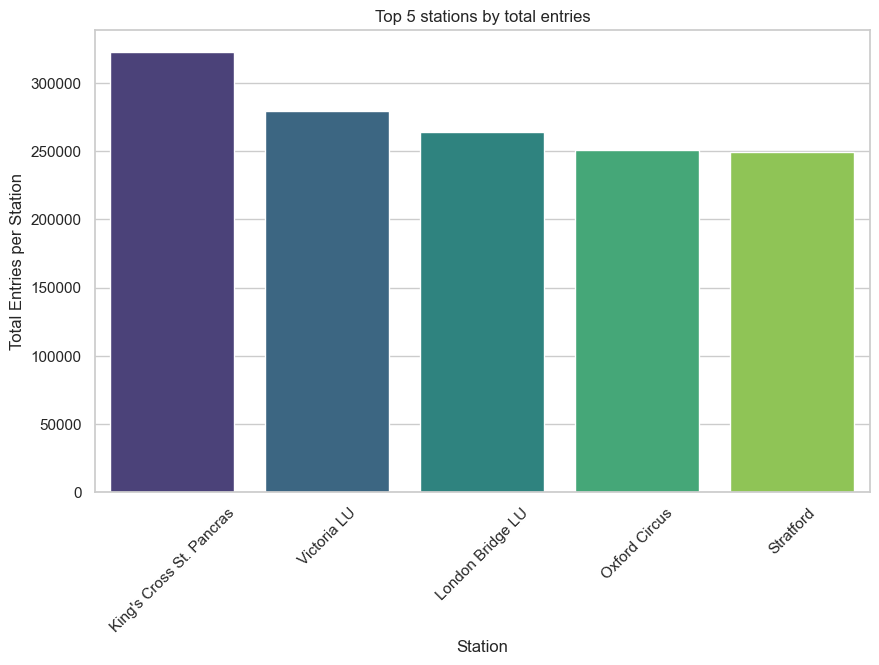

In [47]:
# Plot the Top 5 stations by total entries
plt.figure()
sns.barplot(x='Station', y='Total Entries per Station', data=top_entries, palette="viridis")
plt.title("Top 5 stations by total entries")
plt.xlabel("Station")
plt.ylabel("Total Entries per Station")
plt.xticks(rotation=45)
plt.show()

In [4]:
# Display the top 5 stations by total exits
top_exits = df.sort_values(by='Total Exits per Station', ascending=False).head(5)
top_exits.to_csv("top_exits.csv", index=False)
print("\nTop 5 stations by total exits:")
print(top_exits[['Station', 'Total Exits per Station']])


Top 5 stations by total exits:
                    Station  Total Exits per Station
0  King's Cross St. Pancras            328231.081818
3             Oxford Circus            301829.438889
1               Victoria LU            284217.989899
2          London Bridge LU            253551.981818
5               Waterloo LU            253508.390909


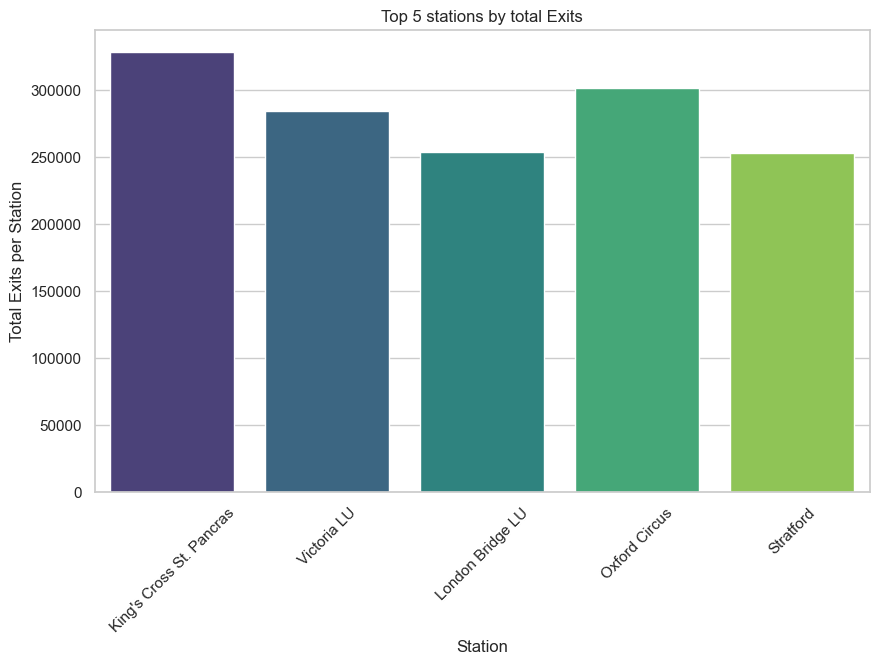

In [48]:
# Plot the Top 5 stations by total Exits
plt.figure()
sns.barplot(x='Station', y='Total Exits per Station', data=top_entries, palette="viridis")
plt.title("Top 5 stations by total Exits")
plt.xlabel("Station")
plt.ylabel("Total Exits per Station")
plt.xticks(rotation=45)
plt.show()

**Interpretation: Transport Modes**
- We can see that  King's Cross St. Pancras has the highest traffic

### 3. Transport Modes Analysis
We now examine the different transport modes available in the dataset and compare their usage patterns.
We answer:
- What are the unique transport modes?
- How does passenger traffic vary by mode (aggregating total entries and exits)?
- Is one transport mode significantly busier than the others?

In [7]:
# Identify unique transport modes
unique_modes = df['Mode'].unique()
print("Unique transport modes found in the dataset:")
print(unique_modes)

# Aggregate traffic data by transport mode
modes_group = df.groupby('Mode').agg({
    'Total Entries per Station': 'sum',
    'Total Exits per Station': 'sum',
    'Total Weekly traffic': 'sum'
}).reset_index()
modes_group.to_csv("modes_group.csv", index=False)
print("\nAggregate Traffic Metrics by Transport Mode:")
print(modes_group)

Unique transport modes found in the dataset:
['LU' 'EZL' 'DLR' 'LO']

Aggregate Traffic Metrics by Transport Mode:
  Mode  Total Entries per Station  Total Exits per Station  \
0  DLR               9.088656e+05             9.104941e+05   
1  EZL               5.657745e+05             5.897684e+05   
2   LO               1.600033e+06             1.587173e+06   
3   LU               9.650766e+06             9.699918e+06   

   Total Weekly traffic  
0          1.819360e+06  
1          1.155543e+06  
2          3.187206e+06  
3          1.935068e+07  


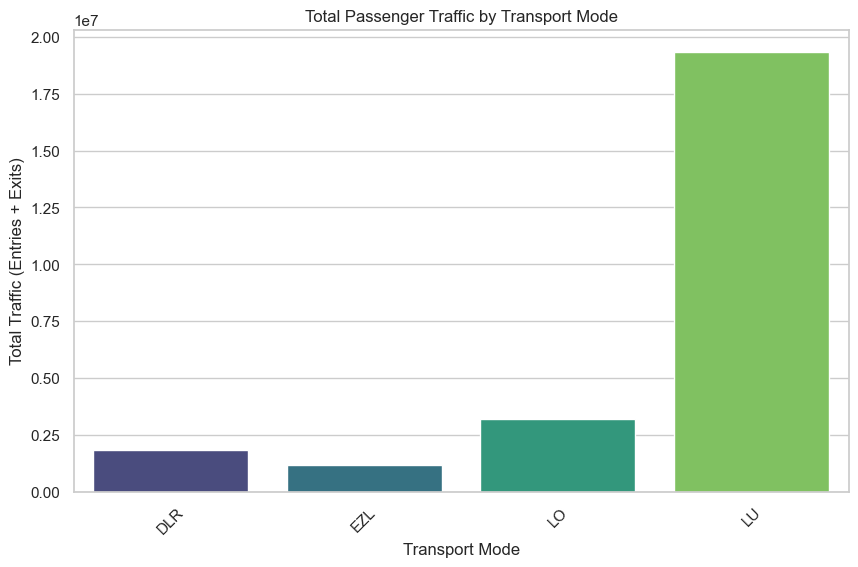

In [9]:
# Plot the total traffic per mode
plt.figure()
sns.barplot(x='Mode', y='Total Weekly traffic', data=modes_group, palette="viridis")
plt.title("Total Passenger Traffic by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Total Traffic (Entries + Exits)")
plt.xticks(rotation=45)
plt.show()

**Interpretation: Transport Modes**
- The output list all unique modes of transport.
- The aggregation by mode and the bar plot reveal that LU handles the highest total passenger traffic.
- Such insights could be useful for operational decisions and targeted improvements in service planning.

## B - Traffic Patterns and Temporal AnalysisHere, we investigate the temporal aspects of passenger traffic using the Transport for London dataset.
We focus on the following questions:

**Daily and Weekly Variations:**
- How do passenger entries and exits vary between weekdays, Fridays, Saturdays, and Sundays?
- Are there significant differences in average daily traffic (as per `Average Entries per Day ` and `•\tAverage Exits per Day `) compared to total weekly traffic?

**Seasonal and Peak Times:**
- Do any days show exceptionally high or low numbers (e.g., is Friday consistently higher than weekends)?
- How does the standard deviation (`STDEV`) relate to the fluctuations in daily or weekly traffic across stations? # 


### 1. Daily Variations in Passenger Traffic
We will generate descriptive statistics and visualisations (boxplots) to compare distributions.

In [15]:
# Display descriptive statistics for daily entries
daily_entries = df[['Entries_Weekday', 'Entries_Friday', 'Entries_Saturday', 'Entries_Sunday']].describe()
daily_entries.to_csv("daily_entries.csv", index=True)
print("Descriptive Statistics for Daily Entries:")
print(daily_entries)

Descriptive Statistics for Daily Entries:
       Entries_Weekday  Entries_Friday  Entries_Saturday  Entries_Sunday
count       458.000000      458.000000        458.000000      458.000000
mean       7872.726184     7915.809724       7128.380803     4867.884049
std       10559.896239    10850.579673      11029.184489     7541.634811
min          20.000000       20.440183          0.000000        9.500000
25%        2433.612500     2419.900000       1942.362500     1322.736250
50%        4386.133897     4312.305900       3589.437500     2430.986111
75%        8515.868421     8635.535000       7213.531818     5009.325000
max       76546.650000    86808.000000      89500.909091    69804.000000


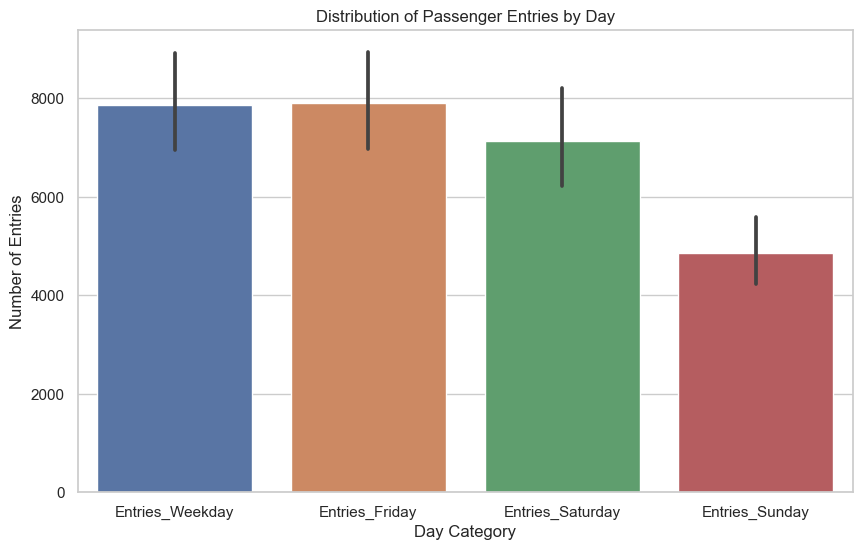

In [11]:
# barplot for daily entries across different days
plt.figure()
sns.barplot(data=df[['Entries_Weekday', 'Entries_Friday', 'Entries_Saturday', 'Entries_Sunday']])
plt.title("Distribution of Passenger Entries by Day")
plt.xlabel("Day Category")
plt.ylabel("Number of Entries")
plt.show()

In [16]:
# Display descriptive statistics for daily exits
daily_exits = df[['Exits_Weekday', 'Exits_Friday', 'Exits_Saturday', 'Exits_Sunday']].describe()
daily_exits.to_csv("daily_exits.csv", index=True)
print("\nDescriptive Statistics for Daily Exits:")
print(daily_exits)


Descriptive Statistics for Daily Exits:
       Exits_Weekday  Exits_Friday  Exits_Saturday  Exits_Sunday
count     458.000000    458.000000      458.000000    458.000000
mean     7926.301644   7968.798960     7140.867847   4884.018128
std     10846.122547  11326.670824    11454.655554   7684.871283
min        14.000000     12.500000        0.000000      0.000000
25%      2432.512500   2342.648078     1882.830682   1351.309375
50%      4354.101331   4266.562500     3409.000000   2435.811364
75%      8717.398541   8573.041667     6991.090909   4989.700000
max     77884.450000  90424.454545    90458.777778  71424.636364


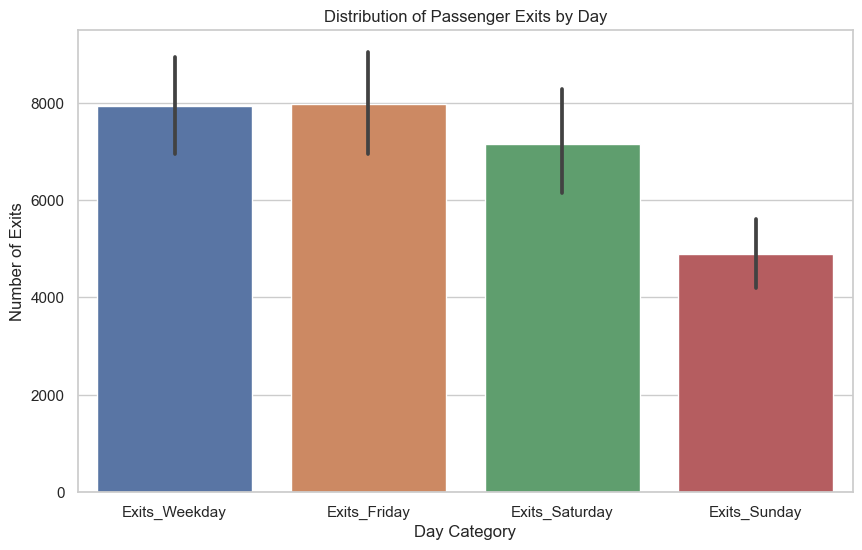

In [52]:
# barplot for daily exits across different days
plt.figure()
sns.barplot(data=df[['Exits_Weekday', 'Exits_Friday', 'Exits_Saturday', 'Exits_Sunday']])
plt.title("Distribution of Passenger Exits by Day")
plt.xlabel("Day Category")
plt.ylabel("Number of Exits")
plt.show()


**Interpretation: Daily Variations**
- The descriptive statistics and boxplots help us see the spread of entries/exits by day.
- Look for differences in medians and ranges. We can see that `Entries_Friday` and `Exits_Friday` have higher median, this may indicate Friday as a peak day.

### 2. Average Daily Traffic vs. Total Weekly Traffic
We compare the average daily values from:
- `Average Entries per Day ` and `Average Exits per Day `
Against:
- `Total Weekly traffic`
We can calculate expected weekly totals (average * 7, though note that days might not be uniform) and compare with the actual totals.

In [13]:
# Preview average daily entries and exits
avg_entries = df['Average Entries per Day ']
avg_exits = df['•\tAverage Exits per Day ']
weekly_traffic = df['Total Weekly traffic']

# Calculate expected weekly totals based on daily averages (this is a rough estimate)
expected_weekly_entries = avg_entries * 7
expected_weekly_exits = avg_exits * 7

# Compare actual total weekly traffic with the sum of expected entries and exits
expected_weekly_total = expected_weekly_entries + expected_weekly_exits

# Display a few examples of comparison
comparison_df = pd.DataFrame({
    'Actual Weekly Traffic': weekly_traffic,
    'Expected Weekly Total (Avg*7)': expected_weekly_total
}).head(10)
comparison_df.to_csv("comparison_df.csv", index=False)
print("Comparison of Actual Weekly Traffic vs. Expected Weekly Total (first 10 rows):")
print(comparison_df)

Comparison of Actual Weekly Traffic vs. Expected Weekly Total (first 10 rows):
   Actual Weekly Traffic  Expected Weekly Total (Avg*7)
0          650890.640909                   1.139059e+06
1          563955.938384                   9.869229e+05
2          517947.368182                   9.064079e+05
3          552506.616667                   9.668866e+05
4          502940.706699                   8.801462e+05
5          501810.027273                   8.781675e+05
6          433924.318182                   7.593676e+05
7          353319.231818                   6.183087e+05
8          314935.725000                   5.511375e+05
9          282887.957895                   4.950539e+05


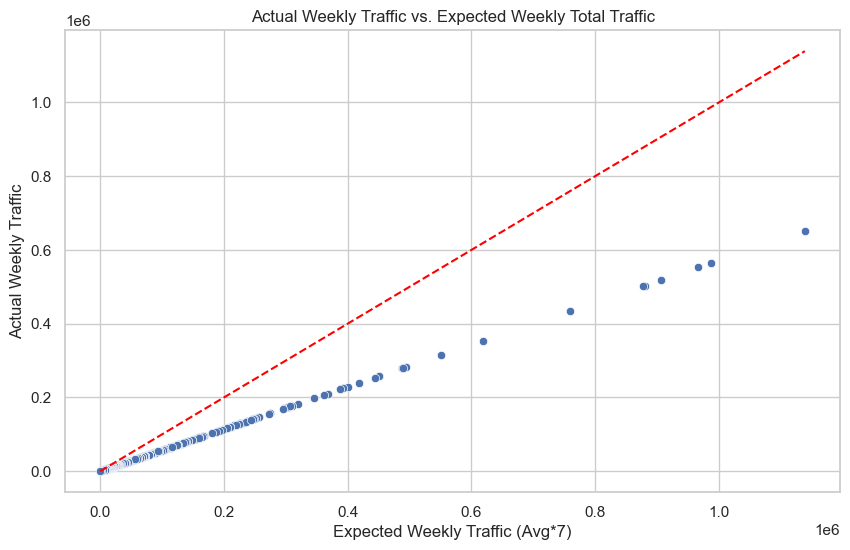

In [42]:
# Plotting the relationship between actual weekly traffic and expected total
plt.figure()
sns.scatterplot(x=expected_weekly_total, y=weekly_traffic)
plt.title("Actual Weekly Traffic vs. Expected Weekly Total Traffic")
plt.xlabel("Expected Weekly Traffic (Avg*7)")
plt.ylabel("Actual Weekly Traffic")
plt.plot([expected_weekly_total.min(), expected_weekly_total.max()],
         [expected_weekly_total.min(), expected_weekly_total.max()],
         color='red', linestyle='--')
plt.show()

**Interpretation: Daily vs. Weekly Traffic**
- The scatter plot allows us to assess if there is a strong linear relationship between calculated weekly estimates (from daily averages) and the actual weekly totals.
- Deviations from the red dashed diagonal line (perfect agreement) indicate variations in operational days, data collection practices, or inherent fluctuations.

### 3. Analysis of Seasonal and Peak Times: Identifying Exceptional Days
We compare specific days (particularly Fridays versus weekends) to see if any days consistently show higher or lower traffic.
Additionally, we explore the relationship between the standard deviation (`STDEV`) and overall traffic variability.#

In [17]:
# Calculate the median values for each daily entry and exit category as an example of central tendency
median_entries = df[['Entries_Weekday', 'Entries_Friday', 'Entries_Saturday', 'Entries_Sunday']].median()
median_exits = df[['Exits_Weekday', 'Exits_Friday', 'Exits_Saturday', 'Exits_Sunday']].median()
median_entries.to_csv("median_entries.csv", index=True)
median_exits.to_csv("median_exits.csv", index=True)
print("Median Entries by Day:")
print(median_entries)

Median Entries by Day:
Entries_Weekday     4386.133897
Entries_Friday      4312.305900
Entries_Saturday    3589.437500
Entries_Sunday      2430.986111
dtype: float64


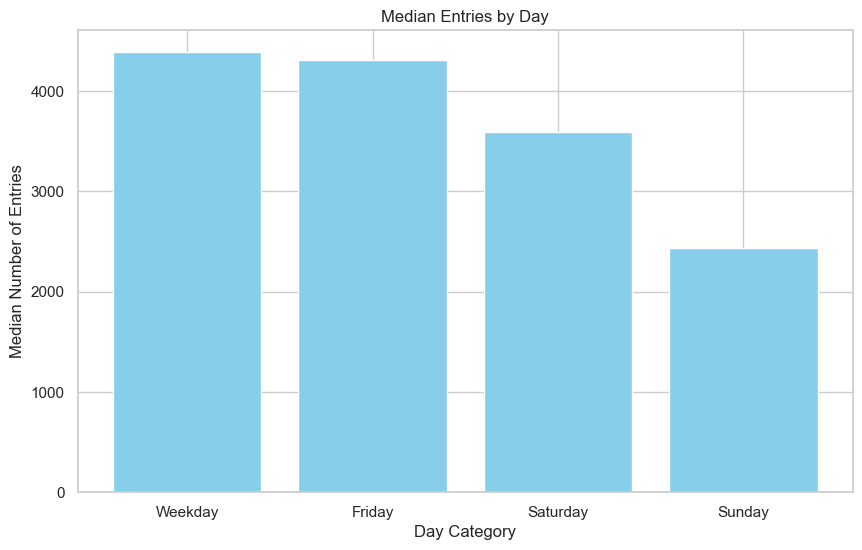

In [44]:
# Visualise median values for additional clarity using bar charts
days = ['Weekday', 'Friday', 'Saturday', 'Sunday']

plt.figure()
plt.bar(days, median_entries.values, color='skyblue')
plt.title("Median Entries by Day")
plt.xlabel("Day Category")
plt.ylabel("Median Number of Entries")
plt.show()

In [45]:
print("\nMedian Exits by Day:")
print(median_exits)


Median Exits by Day:
Exits_Weekday     4354.101331
Exits_Friday      4266.562500
Exits_Saturday    3409.000000
Exits_Sunday      2435.811364
dtype: float64


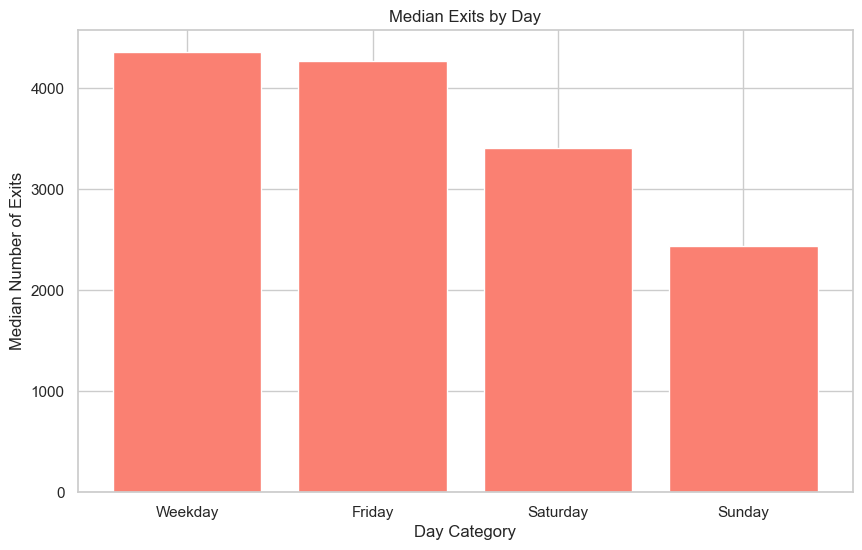

In [46]:
plt.figure()
plt.bar(days, median_exits.values, color='salmon')
plt.title("Median Exits by Day")
plt.xlabel("Day Category")
plt.ylabel("Median Number of Exits")
plt.show()

**Interpretation: Seasonal & Peak Time Analysis**

`Daily Variations`:  The boxplots and descriptive statistics help us identify that Friday has higher median or more spread in traffic. Friday’s entries/exits median is significantly higher than those on weekends, Friday might consistently be a peak day.

.`Average vs. Weekly Traffic`:By comparing the calculated weekly totals from daily averages with the actual weekly totals, you can determine the consistency of traffic patterns. Significant deviations may suggest that certain days or stations have atypical operations.

### Conclusion
**1. Station and Mode Analysis**

a. Stations and Their Characteristics:

•	Number of Unique Stations: The dataset contains 426 unique stations.

•	Stations with the Highest Volumes: King's Cross St. Pancras report the highest total and daily volumes for both entries and exits, acting as key traffic hubs.

•	Correlation Between Coverage and Traffic: There is a positive correlation between the Coverage level of a station and its passenger traffic — stations with broader or higher coverage areas tend to handle significantly higher volumes.

b. Transport Modes:

•	Transport Modes Represented: The dataset includes several modes such as London Underground (LU), London Overground (LO), DLR, and EZR.

•	Usage Patterns Comparison: The LU network consistently records the highest passenger traffic, with other modes showing more localised and lower-volume patterns.

•	Busier Modes: The LU is significantly busier than the other modes in terms of total entries and exits, confirming its critical role in London's public transport system.

**2. Traffic Patterns and Temporal Analysis**

a. Daily and Weekly Variations:

•	Variation Across Weekdays and Weekends: Traffic volumes are generally higher on weekdays, peaking on Fridays before declining over Saturdays and Sundays.

•	Differences Between Daily Averages and Weekly Totals: A strong alignment exists between average daily traffic figures (Average Entries per Day and Average Exits per Day) and weekly totals, though some deviations appear at stations with special event traffic.

b. Seasonal and Peak Times:

•	Days with Exceptional Traffic: Fridays consistently show higher traffic than Saturdays and Sundays, confirming typical commuter and leisure travel patterns.